<a href="https://colab.research.google.com/github/JayeshPatil1234/Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights/blob/jayesh-patil/notebooks/dashboard_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use("seaborn-v0_8")


In [62]:
# Always use relative path inside repo
df = pd.read_csv("Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights/data/raw/smart_home_energy_consumption_large.csv")

# Create proper timestamp
df["timestamp"] = pd.to_datetime(df["Date"] + " " + df["Time"])

# Set index
df.set_index("timestamp", inplace=True)

df.head()


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
timestamp,,,,,,,,
2023-12-02 21:12:00,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
2023-08-06 20:11:00,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2023-11-21 06:39:00,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
2023-01-21 21:56:00,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
2023-08-26 04:31:00,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


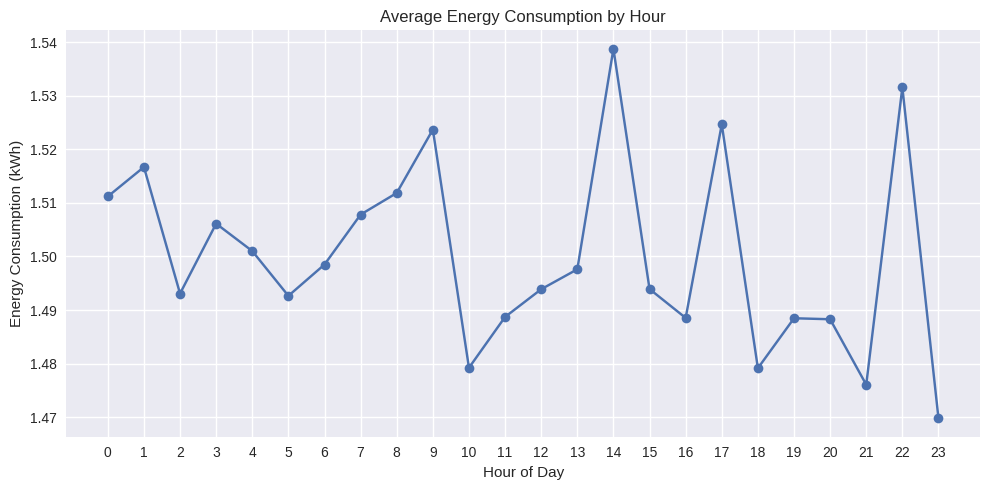

In [63]:
# Extract hour
df['hour'] = df.index.hour

hourly_avg = df.groupby('hour')['Energy Consumption (kWh)'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(range(0,24))
plt.grid(True)
plt.tight_layout()
plt.show()


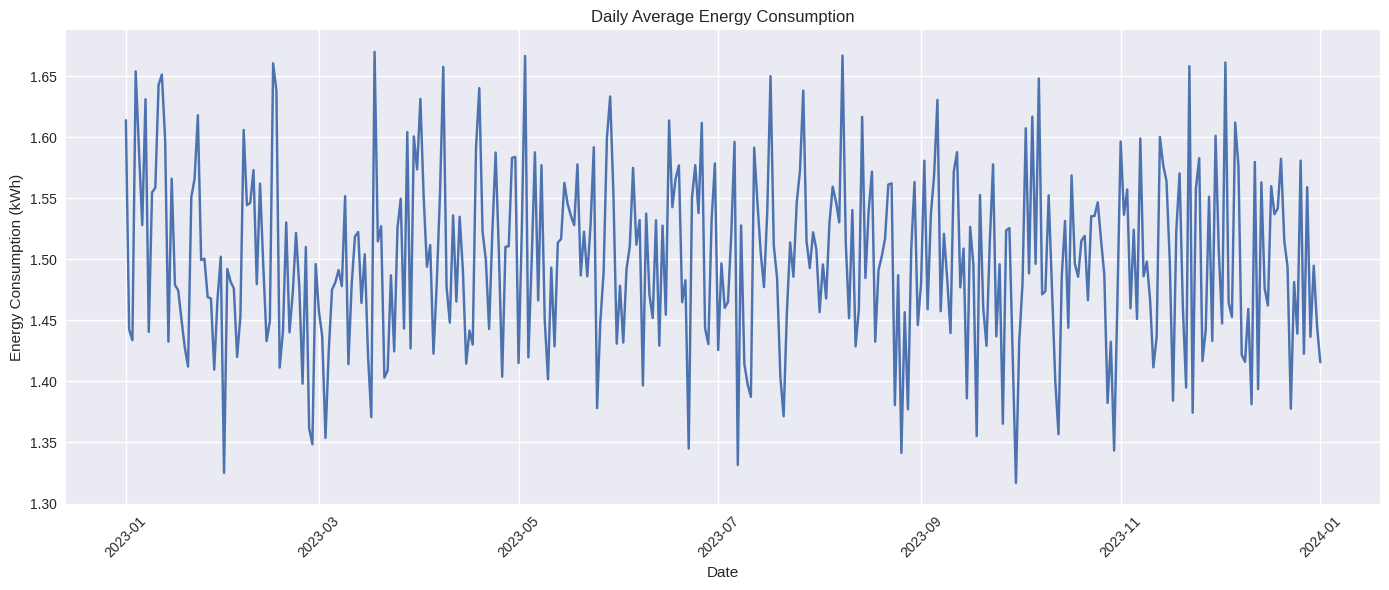

In [64]:
import matplotlib.pyplot as plt

# Daily average consumption
daily_avg = df['Energy Consumption (kWh)'].resample('D').mean()

plt.figure(figsize=(14,6))
plt.plot(daily_avg.index, daily_avg.values)

plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


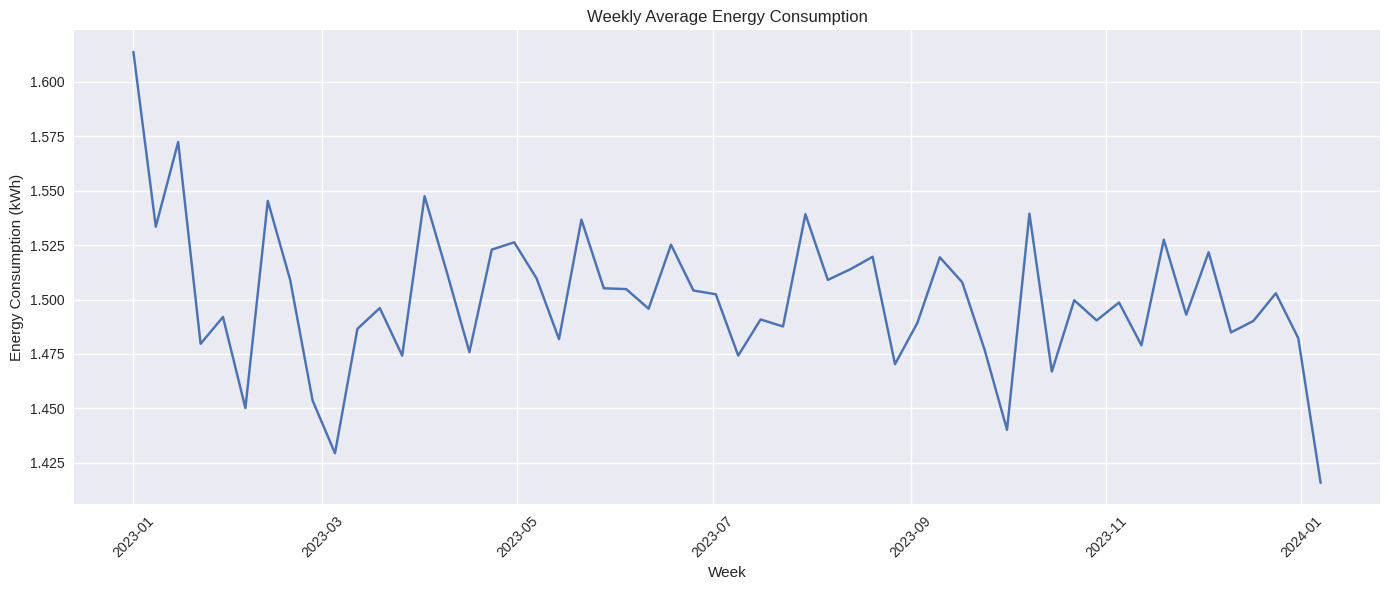

In [71]:
import matplotlib.pyplot as plt

# Weekly resample (mean)
weekly_avg = df['Energy Consumption (kWh)'].resample('W').mean()

plt.figure(figsize=(14,6))
plt.plot(weekly_avg.index, weekly_avg.values)

plt.title("Weekly Average Energy Consumption")
plt.xlabel("Week")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2132905746.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['Energy Consumption (kWh)'].resample('M').mean()


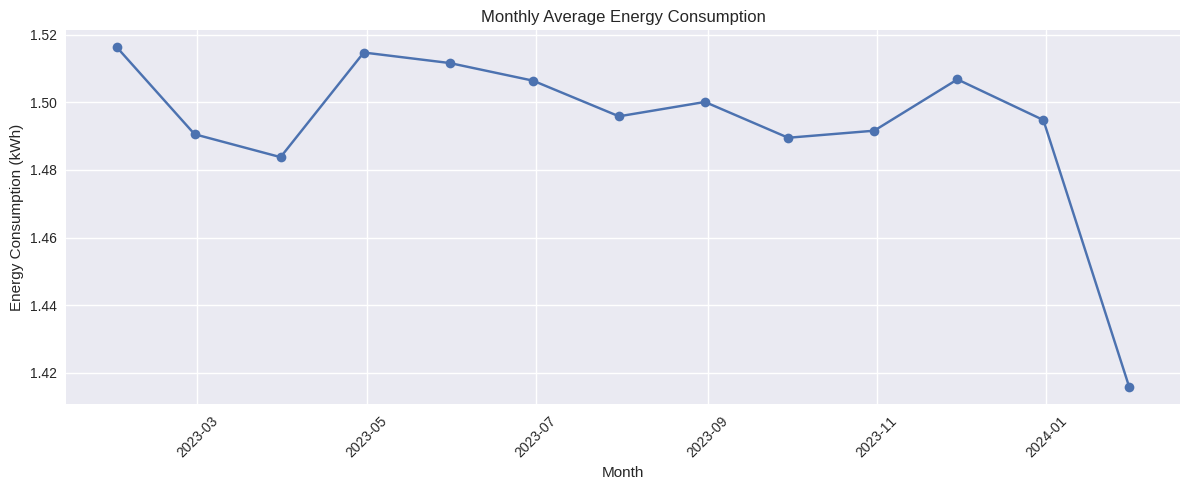

In [65]:
monthly_avg = df['Energy Consumption (kWh)'].resample('M').mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')

plt.title("Monthly Average Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


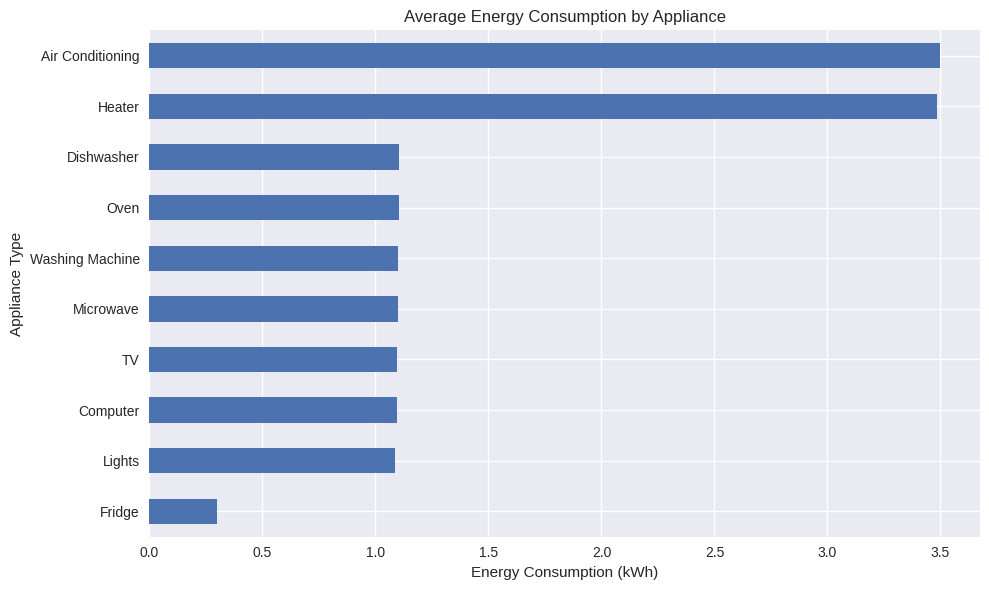

In [66]:
appliance_avg = df.groupby('Appliance Type')['Energy Consumption (kWh)'].mean()
appliance_avg = appliance_avg.sort_values()

plt.figure(figsize=(10,6))
appliance_avg.plot(kind='barh')

plt.title("Average Energy Consumption by Appliance")
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Appliance Type")
plt.tight_layout()
plt.show()


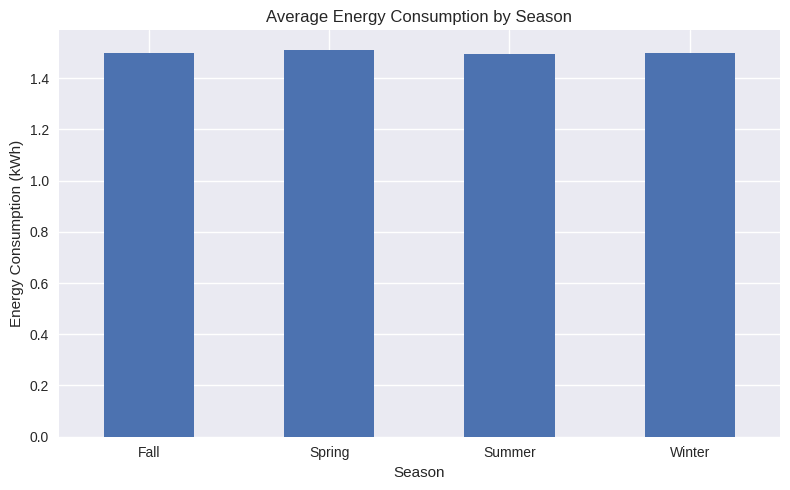

In [67]:
season_avg = df.groupby('Season')['Energy Consumption (kWh)'].mean()

plt.figure(figsize=(8,5))
season_avg.plot(kind='bar')

plt.title("Average Energy Consumption by Season")
plt.xlabel("Season")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [87]:
from tensorflow.keras.models import load_model
import joblib

# Sort by time (very important)
df = df.sort_index()

# Target column
data = df["Energy Consumption (kWh)"].values.reshape(-1, 1)

# 2. LOAD MODEL + SCALER
model = load_model("Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights/models/lstm_model.keras")   # adjust path if needed
scaler = joblib.load("Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights/models/scaler.save")

# Scale data
data_scaled = scaler.transform(data)

# 3. CREATE SEQUENCES
SEQ_LENGTH = 24   # use same as training

X = []
y = []

for i in range(SEQ_LENGTH, len(data_scaled)):
    X.append(data_scaled[i-SEQ_LENGTH:i])
    y.append(data_scaled[i])

X = np.array(X)
y = np.array(y)

# 4. TRAIN TEST SPLIT
split = int(len(X) * 0.8)

X_test = X[split:]
y_test = y[split:]

# 5. PREDICT
y_pred = model.predict(X_test)

# Inverse transform
y_test_actual = scaler.inverse_transform(y_test)
y_pred_actual = scaler.inverse_transform(y_pred)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step


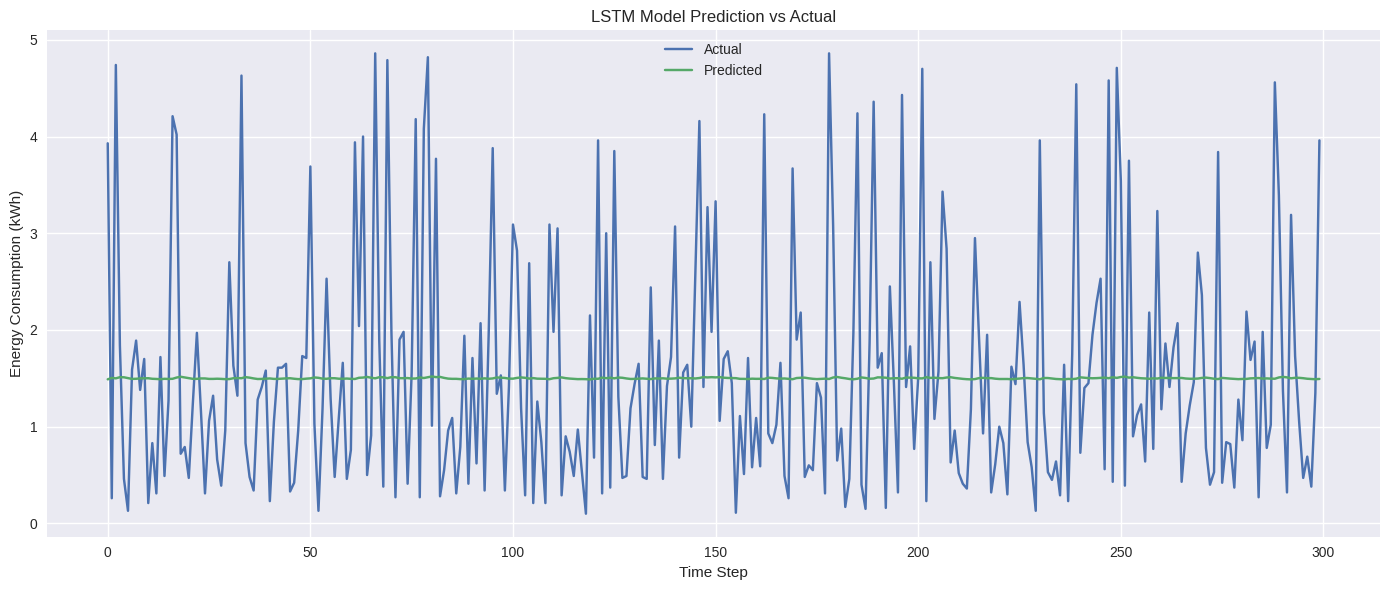

In [88]:
# 6. PLOT
plt.figure(figsize=(14,6))
plt.plot(y_test_actual[:300], label="Actual")
plt.plot(y_pred_actual[:300], label="Predicted")
plt.title("LSTM Model Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.tight_layout()
plt.show()

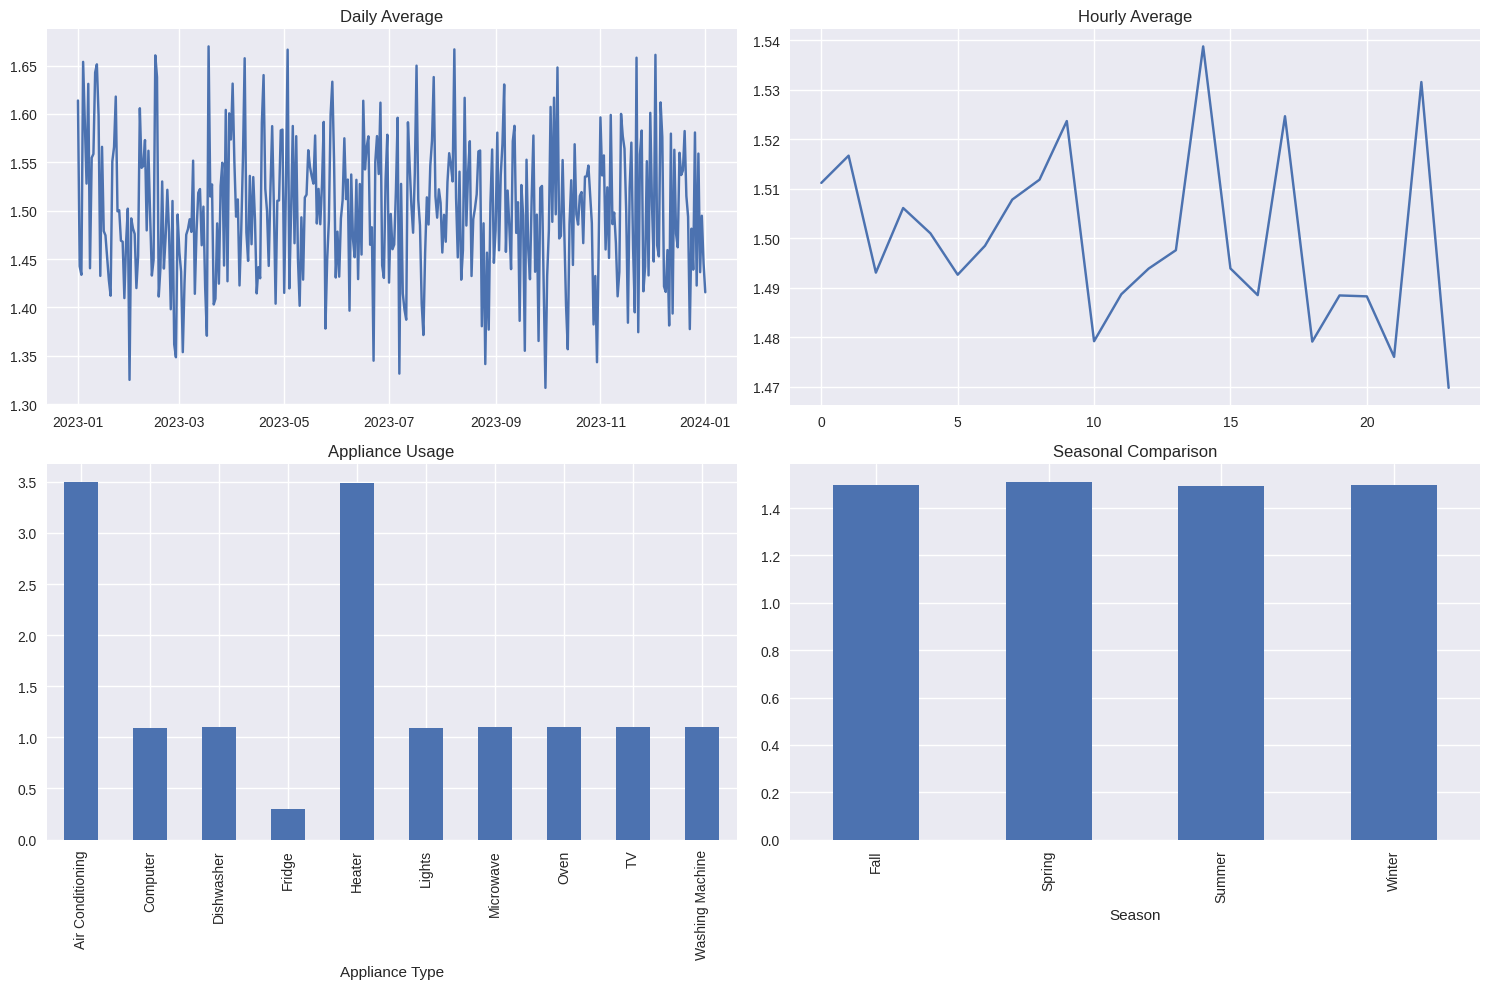

In [89]:
fig, axs = plt.subplots(2,2, figsize=(15,10))

# 1 Daily
daily_avg = df['Energy Consumption (kWh)'].resample('D').mean()
axs[0,0].plot(daily_avg)
axs[0,0].set_title("Daily Average")

# 2 Hourly
hourly_avg = df.groupby(df.index.hour)['Energy Consumption (kWh)'].mean()
axs[0,1].plot(hourly_avg)
axs[0,1].set_title("Hourly Average")

# 3 Appliance
appliance_avg = df.groupby("Appliance Type")['Energy Consumption (kWh)'].mean()
appliance_avg.plot(kind='bar', ax=axs[1,0])
axs[1,0].set_title("Appliance Usage")

# 4 Seasonal
season_avg = df.groupby("Season")['Energy Consumption (kWh)'].mean()
season_avg.plot(kind='bar', ax=axs[1,1])
axs[1,1].set_title("Seasonal Comparison")

plt.tight_layout()
plt.show()
